<a href="https://colab.research.google.com/github/swianto/Tribe2/blob/main/tribe_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 139 packages in 4.66s
Prepared 44 packages in 49.56s
Uninstalled 22 packages in 749ms
Installed 44 packages in 466ms
 - click==8.4.0
 + click==8.1.8
 + cyclopts==4.16.1
 - decorator==4.4.2
 + decorator==5.3.1
 + exca==0.5.25
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.12.1
 + mne-bids==0.19.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.19.0.56
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-cur

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path


model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=Path("./cache"),
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-28 22:29:00 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-28 22:29:10 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [2]:
import os
import shutil
from pathlib import Path
from google.colab import files
from IPython.display import display

try:
    from tribev2.demo_utils import TribeModel

    CACHE_FOLDER = Path("./cache")
    CACHE_FOLDER.mkdir(parents=True, exist_ok=True)

    # Initialize model
    print("Initializing model...")
    model = TribeModel.from_pretrained(
        "facebook/tribev2",
        cache_folder=CACHE_FOLDER,
    )

    # Manual trigger for new upload
    # To use a previously uploaded file, set this to False
    RE_UPLOAD = True

    if RE_UPLOAD:
        print("Please upload your video file:")
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No file uploaded.")
        filename = next(iter(uploaded))
        video_path = CACHE_FOLDER / filename
        shutil.move(filename, video_path)
    else:
        video_files = list(CACHE_FOLDER.glob("*.mp4")) + list(Path("/content").glob("*.mp4"))
        if not video_files:
             raise FileNotFoundError("No videos found in cache. Set RE_UPLOAD=True.")
        video_path = video_files[0]

    print(f"Using video: {video_path}")

    # 1. Get events (transcription and feature extraction)
    print("Extracting events and features...")
    df = model.get_events_dataframe(video_path=video_path)
    display(df.head(8)[["type", "start", "duration", "text"]])

    # 2. Predict brain responses
    print("Generating brain response predictions...")
    preds, segments = model.predict(events=df)
    print(f"\nSuccess! Predictions shape: {preds.shape} (timesteps, vertices)")

except ImportError as e:
    print(f"Error: {e}")
    print("\n--- ACTION REQUIRED ---\nPlease go to 'Runtime' -> 'Restart session', then run this cell again.")

Initializing model...


2026-05-28 22:29:22 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt


Please upload your video file:


Saving Concept BTS - Concept Draft 1.mp4 to Concept BTS - Concept Draft 1.mp4
Using video: cache/Concept BTS - Concept Draft 1.mp4
Extracting events and features...


Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

2026-05-28 22:37:10 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 15.83s at 24.0fps, shape (720, 1280)):
cache/Concept BTS - Concept Draft 1.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 15.83s at 24.0fps, shape (720, 1280)):
cache/Concept BTS - Concept Draft 1.mp4
Encoding video:   0%|          | 0/32 [00:00<?, ?it/s]2026-05-28 22:37:29 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (32, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (32, 20, 1408)
Encoding video: 100%|██████████| 32/32 [09:55<00:00, 18.61s/it]
[22:47:07 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-28 22:47:07 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[22:47:07 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/d


Success! Predictions shape: (16, 20484) (timesteps, vertices)


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [3]:
import os
from huggingface_hub import login, notebook_login

try:
    print("Hugging Face Authentication")
    print("Note: You must accept the Llama 3.2 license at: https://huggingface.co/meta-llama/Llama-3.2-3B")

    # Using notebook_login for a secure interactive prompt
    notebook_login()

    # Run the prediction
    print("\nGenerating brain response predictions (Extracting Llama 3.2 text features)...")
    preds, segments = model.predict(events=df)
    print(f"\nSuccess! Predictions shape: {preds.shape} (n_timesteps, n_vertices)")

except Exception as e:
    print(f"\nError: {e}")
    print("\nTroubleshooting:")
    print("1. Ensure your token has 'Read' permissions.")
    print("2. Ensure you have accepted the Meta Llama 3.2 license on Hugging Face.")

[22:47:57 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text


Hugging Face Authentication
Note: You must accept the Llama 3.2 license at: https://huggingface.co/meta-llama/Llama-3.2-3B

Generating brain response predictions (Extracting Llama 3.2 text features)...


[22:47:57 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
[22:47:58 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video
[22:47:58 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-28 22:47:58 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[22:47:58 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1


Success! Predictions shape: (16, 20484) (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  6.71it/s]


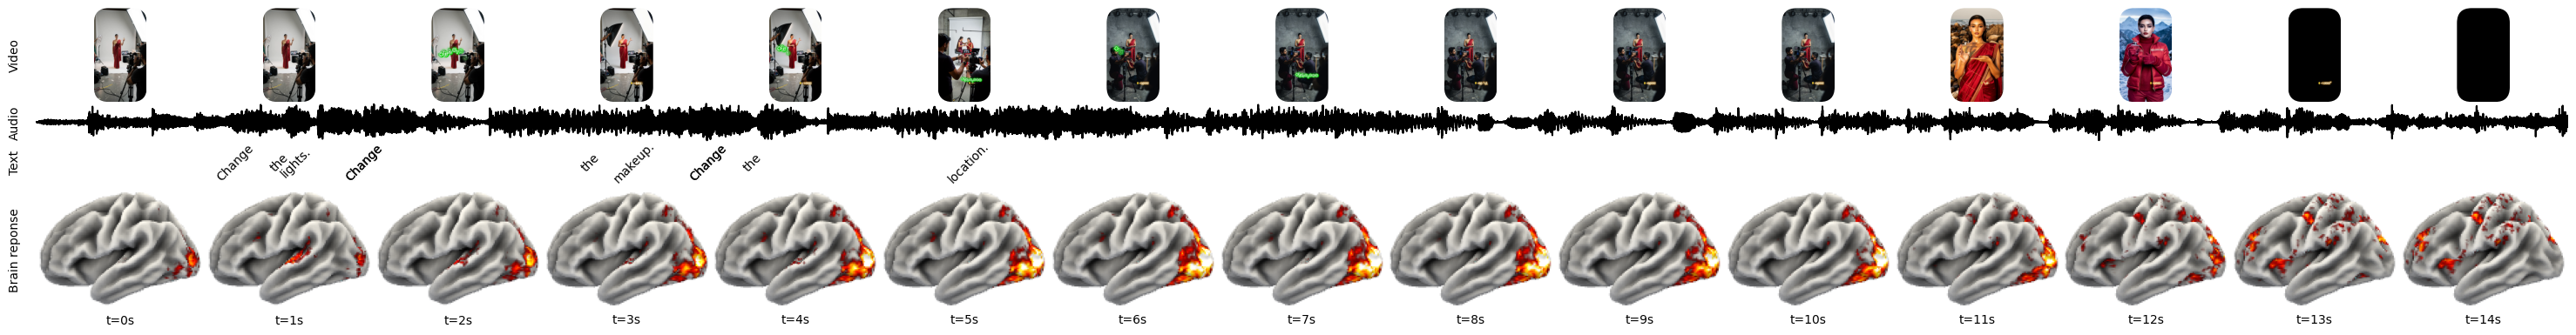

In [5]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [11]:
import json
import numpy as np
from google.colab import files

# Prepare summary matching the visualization exactly
summary_data = []
limit = min(len(segments), len(preds), 15)

for i in range(limit):
    seg = segments[i]
    start_t = seg.start
    end_t = seg.start + seg.duration

    # Filter the dataframe 'df' for text/words appearing in this 1-second window
    mask = (df['start'] >= start_t) & (df['start'] < end_t) & (df['type'].isin(['Text', 'Word', 'Sentence']))
    segment_text = " ".join(df[mask]['text'].fillna('').astype(str).unique().tolist()).strip()

    entry = {
        "timestep_second": i,
        "video_timestamp": float(start_t),
        "stimulus_text": segment_text,
        "avg_brain_activation": float(np.mean(preds[i])),
        "max_brain_activation": float(np.max(preds[i]))
    }
    summary_data.append(entry)

# Save to JSON file
filename = 'tribe_viz_data_for_claude.json'
with open(filename, 'w') as f:
    json.dump(summary_data, f, indent=2)

print(f"Success! '{filename}' has been generated.")
print("Downloading file to your local machine...")

# Trigger browser download
files.download(filename)

Success! 'tribe_viz_data_for_claude.json' has been generated.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.261002,NaN,To be or not to be.,
2,Text,0.091000,22.590000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.200000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[15:12:25 WARNING] Removing extractor video as there are no corresponding events
[15:12:25 INFO] Preparing extractor: text


[15:12:26 INFO] Preparing extractor: audio
Loading weights: 100%|██████████| 773/773 [00:00<00:00, 8813.53it/s]
[15:12:28 INFO] Preparing extractor: subject_id
2026-03-30 15:12:28 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'bar'}. This was probably not intended.
[15:12:29 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:01<00:00,  1.85s/it]
INFO - Predicted 24 / 100 segments (24.0% kept)


Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...:   0%|          | 0/15 [00:00<?, ?it/s]

Plotting...: 100%|██████████| 15/15 [00:01<00:00, 11.59it/s]


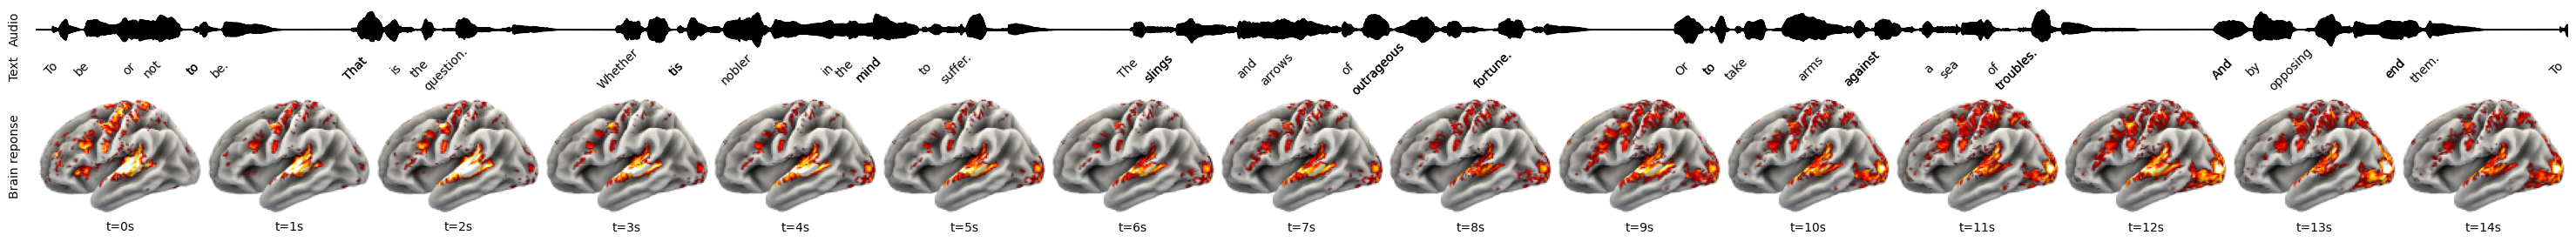

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

### Export Data for Claude / Analysis
This block aggregates the predicted brain activity with the stimulus metadata (text, timestamps) into a structured format.